In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [41]:
df = pd.read_csv(r"C:\Users\HP\Jupyter file\churn-prediction\data\Telco-Customer-Churn.csv", index_col="customerID")
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
customerID,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [45]:
df = df.dropna()
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges'])

In [47]:
df['Churn_Num'] = df['Churn'].map({'No': 0, 'Yes': 1})

In [49]:
# Pivot Table 1: Taux de churn par catégories
print("="*50)
print("📊 PIVOT TABLE 1 : Taux de Churn par Genre")
print("="*50)
pivot_gender = pd.crosstab(df['gender'], df['Churn'], normalize='index') * 100
print(pivot_gender.round(1))
print("\n")

📊 PIVOT TABLE 1 : Taux de Churn par Genre
Churn     No   Yes
gender            
Female  73.0  27.0
Male    73.8  26.2




In [51]:
print("="*50)
print("📊 PIVOT TABLE 2 : Taux de Churn par Senior Citizen")
print("="*50)
pivot_senior = pd.crosstab(df['SeniorCitizen'], df['Churn'], normalize='index') * 100
pivot_senior.index = ['Non-Senior (0)', 'Senior (1)']
print(pivot_senior.round(1))
print("\n")

📊 PIVOT TABLE 2 : Taux de Churn par Senior Citizen
Churn             No   Yes
Non-Senior (0)  76.3  23.7
Senior (1)      58.3  41.7




In [53]:
print("="*50)
print("📊 PIVOT TABLE 3 : Taux de Churn par Type de Contrat")
print("="*50)
pivot_contract = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
print(pivot_contract.round(1))
print("\n")

📊 PIVOT TABLE 3 : Taux de Churn par Type de Contrat
Churn             No   Yes
Contract                  
Month-to-month  57.3  42.7
One year        88.7  11.3
Two year        97.2   2.8




In [55]:
print("="*50)
print("📊 PIVOT TABLE 4 : Taux de Churn par Service Internet")
print("="*50)
pivot_internet = pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100
print(pivot_internet.round(1))

📊 PIVOT TABLE 4 : Taux de Churn par Service Internet
Churn              No   Yes
InternetService            
DSL              81.0  19.0
Fiber optic      58.1  41.9
No               92.6   7.4


In [57]:
# Pivot Table 5: Statistiques moyennes par statut de churn
print("="*50)
print("📊 PIVOT TABLE 5 : Moyennes par Statut de Churn")
print("="*50)
pivot_means = df.groupby('Churn')[['tenure', 'MonthlyCharges', 'TotalCharges']].mean()
print(pivot_means.round(2))
print("\n")

📊 PIVOT TABLE 5 : Moyennes par Statut de Churn
       tenure  MonthlyCharges  TotalCharges
Churn                                      
No      37.65           61.31       2555.34
Yes     17.98           74.44       1531.80




In [59]:
# Pivot Table 6: Aggrégations multiples
print("="*50)
print("📊 PIVOT TABLE 6 : Statistiques Complètes par Churn")
print("="*50)
pivot_stats = df.groupby('Churn').agg({
    'tenure': ['mean', 'median', 'std'],
    'MonthlyCharges': ['mean', 'median', 'std'],
    'TotalCharges': ['mean', 'median', 'std']
}).round(2)
print(pivot_stats)

📊 PIVOT TABLE 6 : Statistiques Complètes par Churn
      tenure               MonthlyCharges               TotalCharges           \
        mean median    std           mean median    std         mean   median   
Churn                                                                           
No     37.65   38.0  24.08          61.31  64.45  31.09      2555.34  1683.60   
Yes    17.98   10.0  19.53          74.44  79.65  24.67      1531.80   703.55   

                
           std  
Churn           
No     2329.46  
Yes    1890.82  


C:\Users\HP\AppData\Local\Temp\ipykernel_14508\2985393118.py:39: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
C:\Users\HP\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


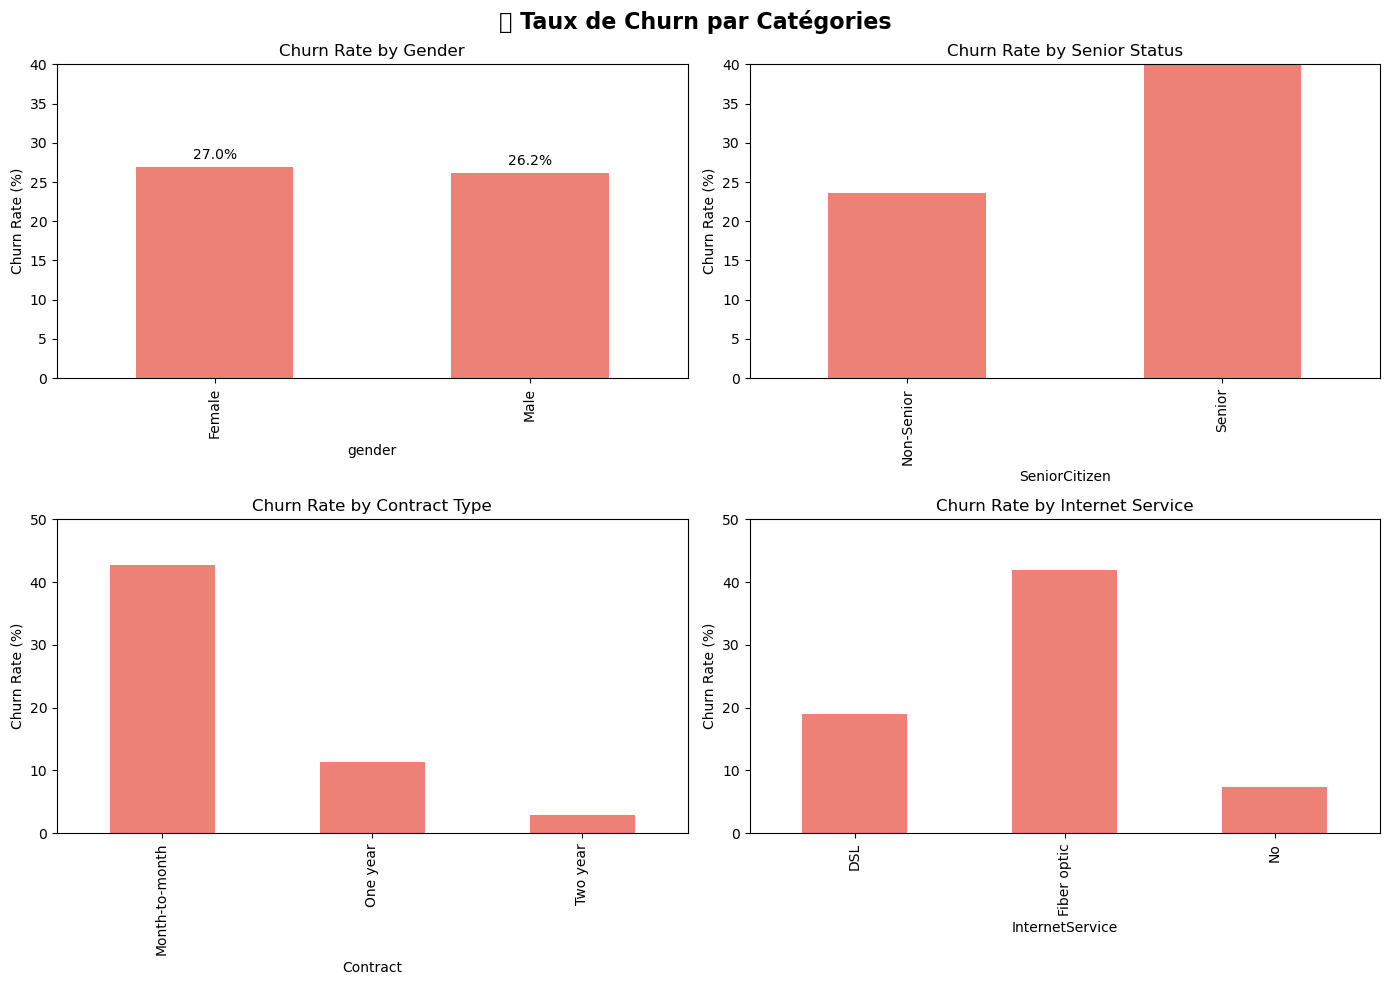

In [61]:
# Configuration des couleurs
colors = ['#2ecc71', '#e74c3c']  # Vert = No Churn, Rouge = Yes Churn

# FIGURE 1: Taux de churn par catégories (Barplots)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('📊 Taux de Churn par Catégories', fontsize=16, fontweight='bold')

# 1.1 Par Genre
gender_pivot = pd.crosstab(df['gender'], df['Churn'], normalize='index') * 100
gender_pivot['Yes'].plot(kind='bar', ax=axes[0, 0], color='#e74c3c', alpha=0.7)
axes[0, 0].set_title('Churn Rate by Gender')
axes[0, 0].set_ylabel('Churn Rate (%)')
axes[0, 0].set_ylim(0, 40)
for i, v in enumerate(gender_pivot['Yes']):
    axes[0, 0].text(i, v + 1, f'{v:.1f}%', ha='center')

# 1.2 Par Senior Citizen
senior_pivot = pd.crosstab(df['SeniorCitizen'], df['Churn'], normalize='index') * 100
senior_pivot['Yes'].plot(kind='bar', ax=axes[0, 1], color='#e74c3c', alpha=0.7)
axes[0, 1].set_title('Churn Rate by Senior Status')
axes[0, 1].set_xticklabels(['Non-Senior', 'Senior'])
axes[0, 1].set_ylabel('Churn Rate (%)')
axes[0, 1].set_ylim(0, 40)

# 1.3 Par Type de Contrat
contract_pivot = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
contract_pivot['Yes'].plot(kind='bar', ax=axes[1, 0], color='#e74c3c', alpha=0.7)
axes[1, 0].set_title('Churn Rate by Contract Type')
axes[1, 0].set_ylabel('Churn Rate (%)')
axes[1, 0].set_ylim(0, 50)

# 1.4 Par Service Internet
internet_pivot = pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100
internet_pivot['Yes'].plot(kind='bar', ax=axes[1, 1], color='#e74c3c', alpha=0.7)
axes[1, 1].set_title('Churn Rate by Internet Service')
axes[1, 1].set_ylabel('Churn Rate (%)')
axes[1, 1].set_ylim(0, 50)

plt.tight_layout()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_14508\3532542341.py:20: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  plt.tight_layout()
C:\Users\HP\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


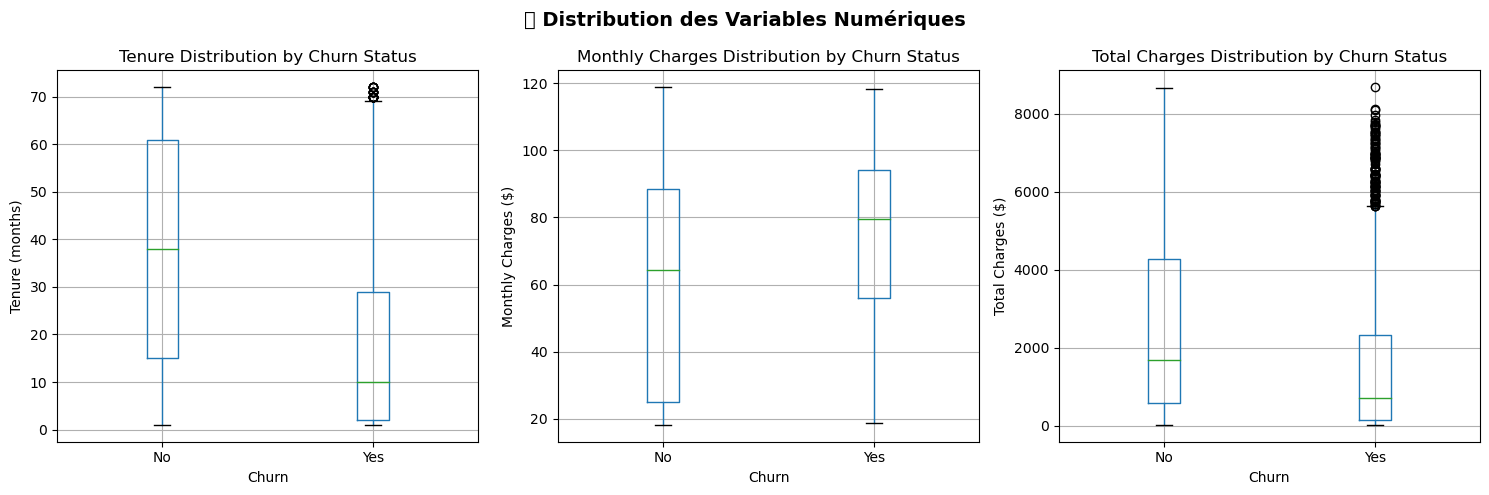

In [63]:
# FIGURE 2: Distribution des variables numériques par churn
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 2.1 Tenure
df.boxplot(column='tenure', by='Churn', ax=axes[0])
axes[0].set_title('Tenure Distribution by Churn Status')
axes[0].set_ylabel('Tenure (months)')

# 2.2 MonthlyCharges
df.boxplot(column='MonthlyCharges', by='Churn', ax=axes[1])
axes[1].set_title('Monthly Charges Distribution by Churn Status')
axes[1].set_ylabel('Monthly Charges ($)')

# 2.3 TotalCharges
df.boxplot(column='TotalCharges', by='Churn', ax=axes[2])
axes[2].set_title('Total Charges Distribution by Churn Status')
axes[2].set_ylabel('Total Charges ($)')

plt.suptitle('📈 Distribution des Variables Numériques', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_14508\1528866788.py:17: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from current font.
  plt.tight_layout()
C:\Users\HP\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


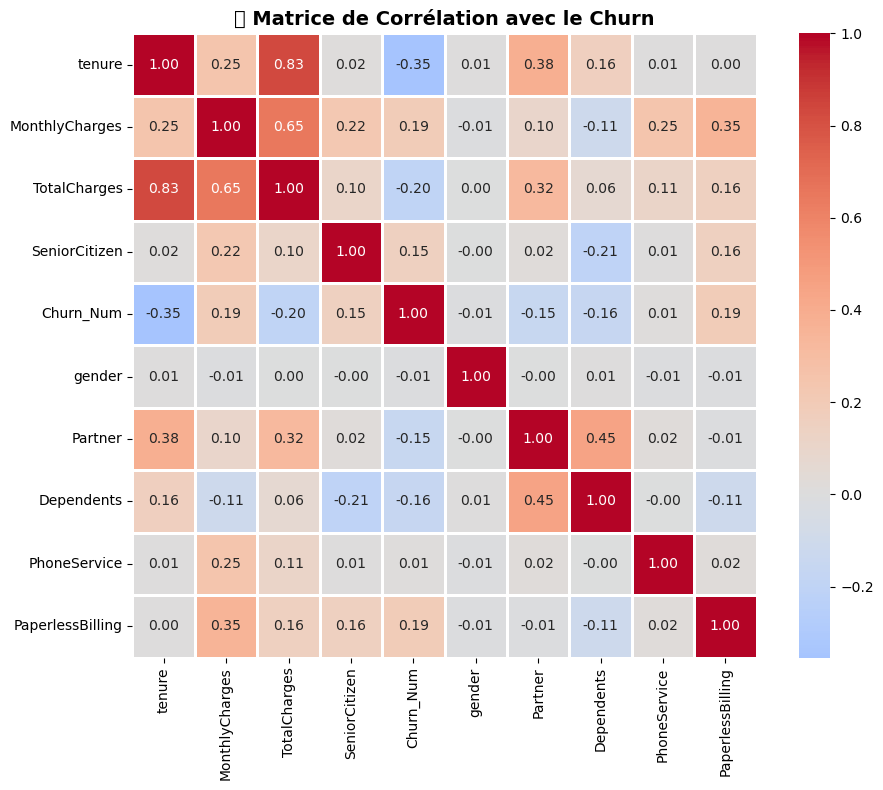

In [65]:
# FIGURE 3: Matrice de corrélation
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_Num']

# Ajouter quelques features catégorielles encodées
df_encoded = df.copy()
cat_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in cat_cols:
    df_encoded[col] = df_encoded[col].map({'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0})

# Créer la matrice de corrélation
corr_matrix = df_encoded[numeric_cols + cat_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=1)
plt.title('🔍 Matrice de Corrélation avec le Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

📊 PIVOT TABLE AVANCÉE : Taux de Churn (%)
Contract Type × Internet Service
Churn                             No   Yes
Contract       InternetService            
Month-to-month DSL              67.8  32.2
               Fiber optic      45.4  54.6
               No               81.1  18.9
One year       DSL              90.7   9.3
               Fiber optic      80.7  19.3
               No               97.5   2.5
Two year       DSL              98.1   1.9
               Fiber optic      92.8   7.2
               No               99.2   0.8




C:\Users\HP\AppData\Local\Temp\ipykernel_14508\615692389.py:28: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
C:\Users\HP\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


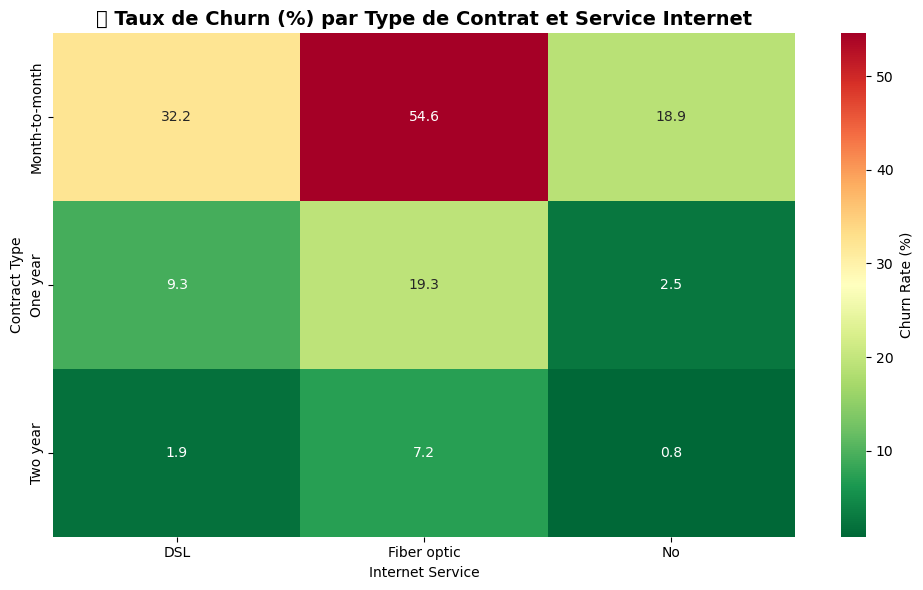

In [67]:
# Pivot Table Avancée: Contrat × InternetService
print("="*60)
print("📊 PIVOT TABLE AVANCÉE : Taux de Churn (%)")
print("Contract Type × Internet Service")
print("="*60)

pivot_multi = pd.crosstab(
    [df['Contract'], df['InternetService']], 
    df['Churn'], 
    normalize='index'
) * 100

# Formater et afficher
pivot_multi_formatted = pivot_multi.round(1)
print(pivot_multi_formatted)
print("\n")

# Visualisation de cette pivot table
plt.figure(figsize=(10, 6))
pivot_heat = pd.crosstab(df['Contract'], df['InternetService'], 
                          values=df['Churn_Num'], aggfunc='mean') * 100
sns.heatmap(pivot_heat, annot=True, fmt='.1f', cmap='RdYlGn_r', 
            cbar_kws={'label': 'Churn Rate (%)'})
plt.title('📊 Taux de Churn (%) par Type de Contrat et Service Internet', 
          fontsize=14, fontweight='bold')
plt.ylabel('Contract Type')
plt.xlabel('Internet Service')
plt.tight_layout()
plt.show()

In [69]:
# Générer un résumé automatique des pivot tables
print("\n" + "="*60)
print("💡 TOP INSIGHTS - Ce qui influence le plus le Churn")
print("="*60)

insights = []

# 1. Contrat
churn_contract = df.groupby('Contract')['Churn_Num'].mean() * 100
worst_contract = churn_contract.idxmax()
best_contract = churn_contract.idxmin()
insights.append(f"📆 Type de contrat : {worst_contract} a {churn_contract[worst_contract]:.1f}% de churn (vs {churn_contract[best_contract]:.1f}% pour {best_contract})")

# 2. Internet Service
churn_internet = df.groupby('InternetService')['Churn_Num'].mean() * 100
worst_internet = churn_internet.idxmax()
insights.append(f"🌐 Service Internet : {worst_internet} a {churn_internet[worst_internet]:.1f}% de churn")

# 3. Paperless Billing
churn_paperless = df.groupby('PaperlessBilling')['Churn_Num'].mean() * 100
insights.append(f"📄 Facture sans papier : {churn_paperless['Yes']:.1f}% de churn (vs {churn_paperless['No']:.1f}% sans)")

# 4. Tenure
tenure_churn_early = df[df['tenure'] <= 12]['Churn_Num'].mean() * 100
tenure_churn_late = df[df['tenure'] > 12]['Churn_Num'].mean() * 100
insights.append(f"⏱️ Ancienneté : clients < 1 an = {tenure_churn_early:.1f}% churn vs > 1 an = {tenure_churn_late:.1f}% churn")

# Afficher les insights
for insight in insights:
    print(insight)

print("\n🎯 Action Recommandée :")
print("- Priorité : Cibler les clients avec contrat Month-to-month + Fiber optic")
print("- Offrir des réductions sur les engagements long terme (2 ans)")
print("- Proposer des services de support technique aux seniors")


💡 TOP INSIGHTS - Ce qui influence le plus le Churn
📆 Type de contrat : Month-to-month a 42.7% de churn (vs 2.8% pour Two year)
🌐 Service Internet : Fiber optic a 41.9% de churn
📄 Facture sans papier : 33.6% de churn (vs 16.4% sans)
⏱️ Ancienneté : clients < 1 an = 47.7% churn vs > 1 an = 17.1% churn

🎯 Action Recommandée :
- Priorité : Cibler les clients avec contrat Month-to-month + Fiber optic
- Offrir des réductions sur les engagements long terme (2 ans)
- Proposer des services de support technique aux seniors
